# 一文掌握模型优化：从诊断分析到高级调优

**模型优化**（Model Optimization）是机器学习工作流中继“模型评估”之后的关键环节。如果说模型评估是体检，那么模型优化就是针对性的治疗方案。本文将从**模型诊断**出发，深入探讨**超参数调优**、**数据平衡处理**以及**正则化技术**，帮助你构建出性能更强、泛化更好的机器学习模型。

---

## 1. 核心概念 —— 优化的维度与流程

一个成熟的机器学习模型不仅仅依赖于算法的选择，更取决于对细节的持续打磨与迭代。在工程实践中，我们建议遵循以下标准化的优化闭环：

1. **诊断分析**

   - **核心任务**：像医生看病一样，首先通过**学习曲线 (Learning Curve)**、**验证曲线 (Validation Curve)** 等可视化工具，准确判断模型当前是处于**欠拟合 (High Bias)** 还是**过拟合 (High Variance)** 状态。
   - **意义**：明确优化方向，避免盲目尝试。例如，对于欠拟合模型，增加数据量通常无效，而应增加模型复杂度。

2. **超参数调优 (Hyperparameter Tuning)**

   - **核心任务**：在确定了算法大类后，利用 **GridSearchCV** 或 **RandomizedSearchCV** 等自动化搜索策略，在多维参数空间中寻找最优配置（如随机森林的树数量、SVM 的核函数参数）。
   - **意义**：挖掘模型潜能，将预测精度提升至当前算法的理论上限。

3. **数据平衡处理**

   - **核心任务**：针对类别分布不均（Imbalanced Data）的场景（如欺诈检测），采用 **SMOTE**（过采样）或 **ClusterCentroids**（欠采样）等技术重构训练集分布。
   - **意义**：消除模型对多数类的偏见，提升对少数类样本（通常是关注重点）的识别能力。

4. **正则化约束 (Regularization)**
   - **核心任务**：在损失函数中引入惩罚项（如 **L1 Lasso** 或 **L2 Ridge**），强制模型参数保持稀疏或平滑。
   - **意义**：通过限制模型复杂度，牺牲少量训练精度以换取更强的**泛化能力**，防止模型在未知数据上“翻车”。

---

## 2. 模型诊断

在深入进行耗时的超参数搜索之前，**模型诊断**是必不可少的战略步骤。盲目调参就像在黑暗中射箭，效率极低且容易偏离目标。我们需要首先明确模型的核心问题是**偏差 (Bias)** 过高（即欠拟合，模型没学会）还是**方差 (Variance)** 过高（即过拟合，模型死记硬背）。只有“确诊”了病因，才能对症下药，选择增加复杂度还是引入正则化等针对性方案。

### 2.1 学习曲线

**学习曲线 (Learning Curve)** 直观地展示了模型性能随着训练样本数量增加而变化的情况。它通过对比**训练集得分**与**验证集得分**的动态关系，帮助我们快速定位模型的泛化瓶颈。

| **诊断状态** | **曲线特征**                                                     | **核心问题**                                   | **优化对策** (Remedies)                                                                                                                                            |
| :----------- | :--------------------------------------------------------------- | :--------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **欠拟合**   | 训练得分与验证得分**均较低**，且两者**趋于收敛**（差距很小）。   | **高偏差**：模型太简单，无法捕捉数据中的规律。 | (1) **增加复杂度**：选用更强大的模型（如增加树深、神经网络层数）；(2) **特征工程**：引入多项式特征、组合特征；(3) **减弱约束**：降低正则化力度（如减小 `alpha`）。 |
| **过拟合**   | 训练得分**很高**，但验证得分**较低**，两者之间存在**显著差距**。 | **高方差**：模型太复杂，记住了训练集的噪声。   | (1) **扩充数据**：收集更多训练样本；(2) **简化模型**：减少特征数量（特征选择）、降低树深；(3) **增强约束**：增大正则化力度（如 L1/L2 惩罚）。                      |

### 2.2 代码示例：绘制学习曲线

以下示例使用 Scikit-Learn 的 `learning_curve` 工具，针对 **手写数字识别 (Digits)** 任务中的 **SVM 分类器** 绘制学习曲线。

**实验目的**：观察随着训练样本数量的增加（从 10% 到 100%），模型在训练集和验证集上的准确率变化趋势，从而判断模型是否存在过拟合或欠拟合。





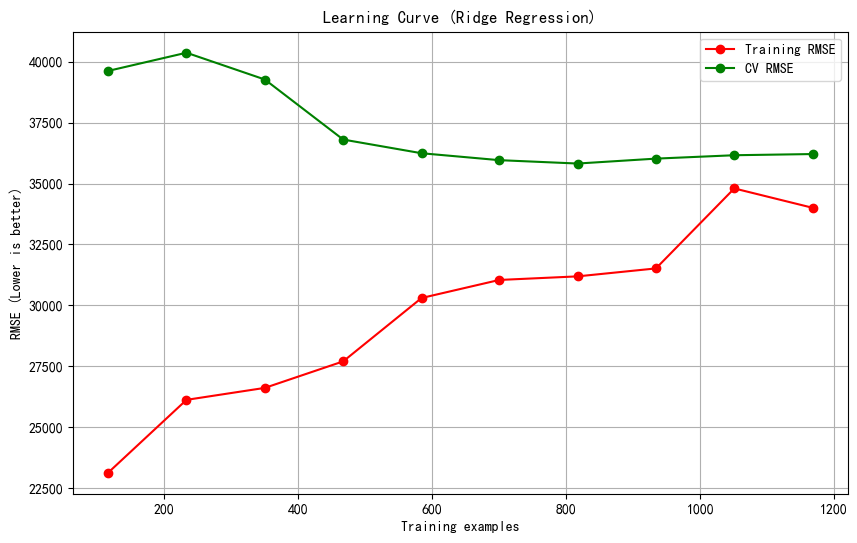

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. 加载数据
data_path = '../ch-04/06_综合案例_Kaggle房价预测/train.csv'
df = pd.read_csv(data_path)

# 2. 预处理：仅使用数值特征，填充缺失值
numeric_features = df.select_dtypes(include=[np.number]).drop(['Id', 'SalePrice'], axis=1).columns
X = df[numeric_features]
y = df['SalePrice']

# 3. 定义模型 (使用 Pipeline 处理标准化)
# 使用 Ridge 回归，因为它比普通线性回归更稳定
model = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge(alpha=1.0))

# 4. 计算学习曲线
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error' # 回归任务常用评分
)

# 转换为 RMSE (均方根误差) 便于理解
train_scores_rmse = np.sqrt(-train_scores)
test_scores_rmse = np.sqrt(-test_scores)

train_mean = np.mean(train_scores_rmse, axis=1)
test_mean = np.mean(test_scores_rmse, axis=1)

# 5. 绘图
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training RMSE")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="CV RMSE")
plt.xlabel("Training examples")
plt.ylabel("RMSE (Lower is better)")
plt.legend(loc="best")
plt.title("Learning Curve (Ridge Regression)")
plt.grid(True)
plt.show()


---

## 3. 超参数调优

**超参数 (Hyperparameters)** 指的是那些无法从数据中自动学习、必须在模型训练前人为设定的配置参数。它们就像是收音机的旋钮，决定了模型的“频段”和“灵敏度”。常见的超参数包括：

- **结构参数**：如 KNN 的邻居数 `n_neighbors`、随机森林的树数量 `n_estimators`。
- **优化参数**：如学习率 `learning_rate`、正则化系数 `C` 或 `alpha`。

超参数的选择直接决定了模型的上限，而我们的目标就是找到那组能让模型性能达到极致的参数组合。

### 3.1 网格搜索 (GridSearchCV)

**GridSearchCV**（网格搜索）是一种**暴力穷举**的搜索策略。它会遍历用户定义的每一个参数组合，结合交叉验证（Cross-Validation）评估其性能，最终锁定得分最高的组合。

- **工作原理**：
  假设参数 A 有 3 种取值，参数 B 有 4 种取值，GridSearchCV 会训练 $3 \times 4 = 12$ 次模型（若 cv=5，则实际训练 $12 \times 5 = 60$ 次）。
- **适用场景**：
  参数数量少、取值范围明确且离散（如 SVM 的核函数类型、KNN 的邻居数）。
- **局限性**：
  随着参数维度的增加，计算代价呈指数级爆炸（Curse of Dimensionality），不适合大范围的参数搜索。

### 3.2 随机搜索 (RandomizedSearchCV)

**RandomizedSearchCV**（随机搜索）采用了一种更灵活的策略：它不是遍历所有组合，而是从指定的参数分布中**随机采样**固定次数（`n_iter`）。

- **工作原理**：
  设定好每个参数的分布范围（如 `randint(1, 100)`），指定总共尝试 100 次。算法会随机抽取 100 组参数进行验证。
- **核心优势**：
  1. **效率高**：可以精确控制计算预算（通过 `n_iter`），不用担心参数过多导致死机。
  2. **探索性强**：对于连续变量（如正则化系数），随机搜索能探索到网格搜索容易遗漏的“中间值”，往往能以更小的代价找到近似最优解。
- **适用场景**：
  参数空间巨大、包含连续变量，或者不确定哪些参数更重要时。

### 3.3 实战：优化随机森林 (GridSearchCV vs RandomizedSearchCV)

本节将演示如何使用两种不同的搜索策略来优化 **随机森林 (RandomForest)** 模型。我们将对比 `GridSearchCV`（网格搜索）与 `RandomizedSearchCV`（随机搜索）的代码实现。

**任务**：在手写数字数据集上，寻找最佳的树数量 (`n_estimators`) 和最大深度 (`max_depth`) 等参数。


### 3.3 实战：优化随机森林 (Regression)

我们将使用随机森林回归模型预测房价。

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# 1. 准备数据
data_path = '../ch-04/06_综合案例_Kaggle房价预测/train.csv'
df = pd.read_csv(data_path)
numeric_features = df.select_dtypes(include=[np.number]).drop(['Id', 'SalePrice'], axis=1).columns
X = df[numeric_features]
y = df['SalePrice']
# 填充缺失值
X = SimpleImputer(strategy='median').fit_transform(X)

# 2. 定义参数空间
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 11),
    'bootstrap': [True, False]
}

# 3. 初始化模型
rf = RandomForestRegressor(random_state=42)

# --- 方式 A: GridSearchCV ---
print("正在执行 GridSearchCV...")
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3, n_jobs=-1, scoring='neg_mean_squared_error'
)
grid_search.fit(X, y)
print(f"GridSearch 最佳参数: {grid_search.best_params_}")
print(f"GridSearch 最佳 RMSE: {np.sqrt(-grid_search.best_score_):.2f}")

# --- 方式 B: RandomizedSearchCV ---
print("\n正在执行 RandomizedSearchCV...")
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,            # 关键：只随机尝试 10 次
    cv=3, n_jobs=-1, scoring='neg_mean_squared_error', random_state=42
)
random_search.fit(X, y)
print(f"RandomSearch 最佳参数: {random_search.best_params_}")
print(f"RandomSearch 最佳 RMSE: {np.sqrt(-random_search.best_score_):.2f}")

正在执行 GridSearchCV...
GridSearch 最佳参数: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
GridSearch 最佳 RMSE: 30675.54

正在执行 RandomizedSearchCV...
RandomSearch 最佳参数: {'bootstrap': True, 'max_depth': 30, 'min_samples_split': 9, 'n_estimators': 70}
RandomSearch 最佳 RMSE: 30920.50


### 4. 特征重要性分析

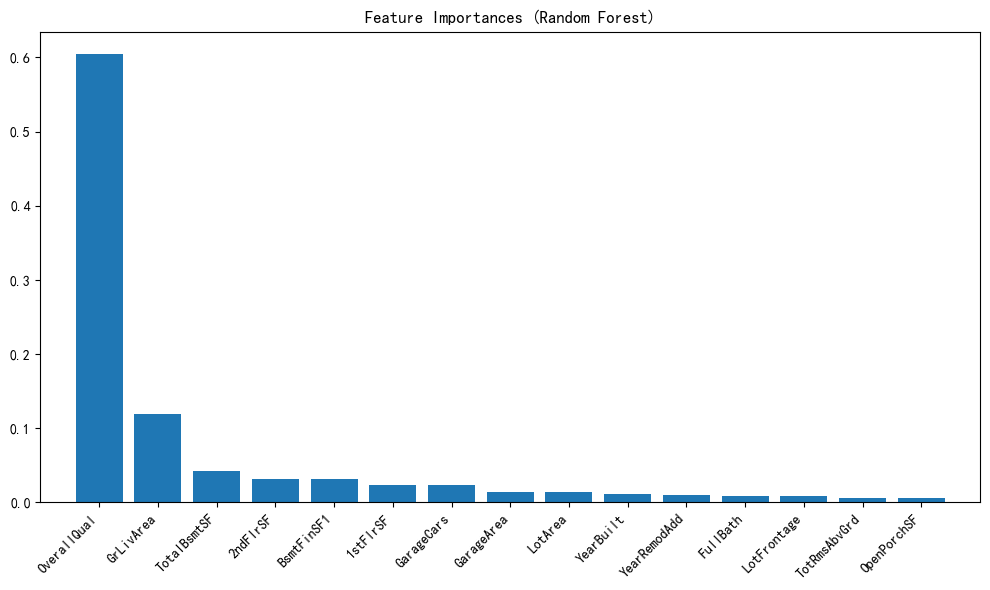

In [3]:

# 4. (新增) 可视化：特征重要性
import matplotlib.pyplot as plt

best_rf = random_search.best_estimator_
importances = best_rf.feature_importances_
# 获取特征名称 (需要重新获取列名)
feature_names = numeric_features

# 排序
indices = np.argsort(importances)[::-1]
top_k = 15 # 展示前15个重要特征

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(top_k), importances[indices[:top_k]], align="center")
plt.xticks(range(top_k), feature_names[indices[:top_k]], rotation=45, ha='right')
plt.xlim([-1, top_k])
plt.tight_layout()
plt.show()

## 4. 处理类别不平衡 (Handling Imbalanced Data)

在许多真实场景中，我们关心的样本往往是少数派。例如：

- **金融风控**：欺诈交易可能仅占总交易量的 0.1%。
- **医疗诊断**：患病人群相对于健康人群是极少数。

如果直接使用标准算法训练，模型为了追求全局准确率（Accuracy），往往会倾向于忽略少数类（例如全部预测为“正常”也能达到 99.9% 的准确率），但这完全背离了我们的业务目标。因此，必须进行**数据平衡处理**。

### 4.1 常用策略

解决不平衡问题主要有三个流派：调整算法对不同类别的重视程度、增加少数类样本（过采样）或减少多数类样本（欠采样）。

1. **调整类别权重 (Class Weight)**

   - **原理**：不改变数据分布，而是修改算法的损失函数。给予少数类更高的**误分类惩罚**，迫使模型更关注少数类。
   - **实现**：大多数 Scikit-Learn 模型（如随机森林、SVM）都有 `class_weight='balanced'` 参数。
   - **评价**：成本最低，首选方案。

2. **过采样 (Oversampling)**

   - **原理**：人为增加少数类样本。
   - **代表算法**：**SMOTE (Synthetic Minority Over-sampling Technique)**。它不是简单复制，而是在少数类样本及其“近邻”之间进行线性插值，合成**全新**的样本。
   - **优点**：丰富了少数类的特征空间，缓解过拟合。

3. **欠采样 (Undersampling)**
   - **原理**：人为减少多数类样本。
   - **代表算法**：**ClusterCentroids**。利用 K-Means 聚类，将多数类样本替换为簇中心（Centroids）。
   - **优点**：大幅减少数据量，加速训练；保留了数据的几何结构。
   - **缺点**：可能会丢失多数类的边界信息。

### 4.2 深入理解 SMOTE 算法

**SMOTE** (Synthetic Minority Over-sampling Technique) 是目前最流行的过采样算法。其核心思想源于几何学中的**线性插值**：它假设位于两个同类样本连线上的点，大概率也属于该类别。因此，SMOTE 通过在样本间“连线造点”，而非简单复制，从而创造出全新的合成样本。

**算法步骤**：

1. **选点**：对于每个少数类样本 $x_i$，计算其在少数类样本中的 $k$ 近邻（通常 $k=5$）。
2. **配对**：随机从 $k$ 个近邻中选出一个样本 $\hat{x}_i$。
3. **插值**：在 $x_i$ 和 $\hat{x}_i$ 的连线上随机选一点作为新样本：
   $$x_{new} = x_i + \lambda \times (\hat{x}_i - x_i)$$
   其中 $\lambda$ 是 $[0, 1]$ 之间的随机数。

**局限性与改进**：原始 SMOTE 算法比较“盲目”，它在合成样本时只关注少数类内部的几何关系，完全忽略了周围是否存在多数类样本（即不看“敌情”）。这极易导致新生成的样本落入多数类的腹地，造成样本重叠（Overlapping），反而模糊了分类边界。针对这一痛点，学术界提出了多种改进方案：

- **Borderline-SMOTE**：只在分类边界附近的“危险区域”合成样本，强化边界识别能力。
- **ADASYN** (Adaptive Synthetic)：根据样本的学习难度（即周围多数类的密度）自适应地调整合成数量，“难学”的样本多合成一点。

### 4.3 SMOTE 与 Pipeline 的正确结合

在实际工程中，使用 SMOTE 时最容易犯的错误是**数据泄露 (Data Leakage)**。如果在交叉验证之前就对整个数据集进行了 SMOTE 增强，那么验证集中就会包含由训练集生成的合成样本，导致模型评估结果虚高。

**正确的做法**是使用 `imblearn.pipeline.Pipeline`。它能确保 SMOTE **只作用于交叉验证的训练折 (Training Fold)**，而保持验证折 (Validation Fold) 纯净且真实。

以下代码演示了如何构建一个包含 **“SMOTE 过采样 -> 数据标准化 -> 逻辑回归”** 的安全流水线：

In [5]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 定义流水线：SMOTE -> 标准化 -> 逻辑回归
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# 结合 GridSearchCV 使用
# 注意：这里的 X 和 y_class 是上一步生成的
grid = GridSearchCV(pipeline, param_grid={'clf__C': [0.1, 1, 10]}, cv=3, scoring='f1')
# 演示运行 (使用全部特征)
grid.fit(X, y_class)
print(f"最佳 F1 Score: {grid.best_score_:.4f}")

最佳 F1 Score: 0.7581


### 4.4 可视化：SMOTE 的效果

我们将构建一个二分类任务（豪宅 vs 普通），演示 SMOTE 如何平衡数据。

原始类别分布: Counter({0: 1345, 1: 115})
SMOTE后类别分布: Counter({0: 1345, 1: 1345})


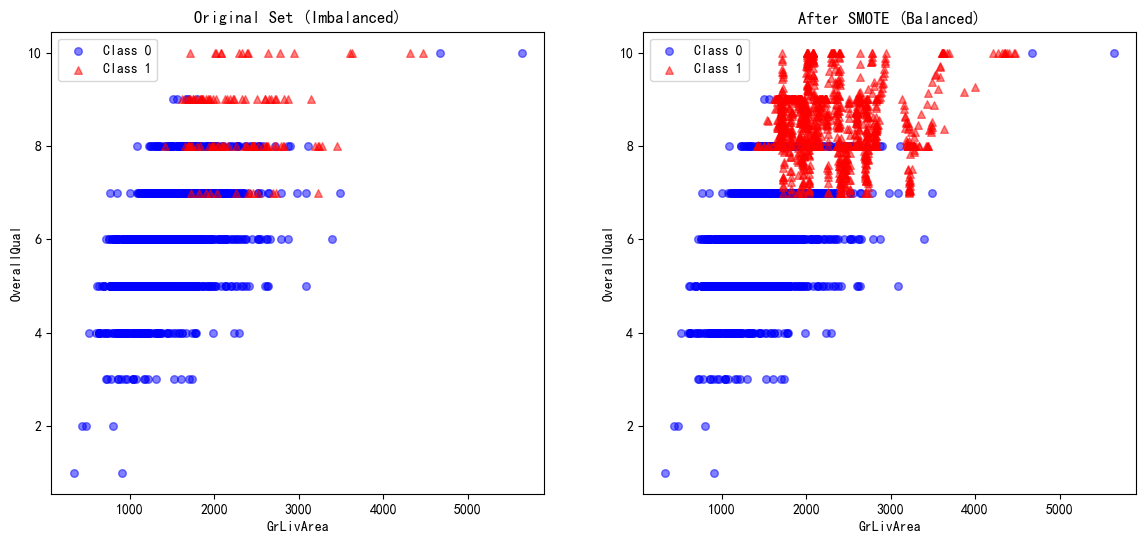

In [4]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# 1. 构造不平衡分类任务
# 定义：售价 > 300,000 为“豪宅” (少数类)
data_path = '../ch-04/06_综合案例_Kaggle房价预测/train.csv'
df = pd.read_csv(data_path)
numeric_features = df.select_dtypes(include=[np.number]).drop(['Id', 'SalePrice'], axis=1).columns
X = df[numeric_features]
X = SimpleImputer(strategy='median').fit_transform(X)

y_raw = df['SalePrice']
threshold = 300000
y_class = (y_raw > threshold).astype(int)

print(f"原始类别分布: {Counter(y_class)}")
# 0: 普通, 1: 豪宅

# 2. 为了可视化，我们只选取两个特征 (GrLivArea, OverallQual)
idx1 = df.columns.get_loc('GrLivArea')
idx2 = df.columns.get_loc('OverallQual')
# 重新构建 X_vis 方便画图 (使用原始df的数据，不带imputer)
X_vis = df[['GrLivArea', 'OverallQual']].values
X_vis = SimpleImputer(strategy='median').fit_transform(X_vis)

# 3. 应用 SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_vis, y_class)

print(f"SMOTE后类别分布: {Counter(y_res)}")

# 4. 可视化对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 绘制原始数据
for label, marker, color in zip([0, 1], ['o', '^'], ['blue', 'red']):
    ax1.scatter(X_vis[y_class == label, 0], X_vis[y_class == label, 1],
                label=f"Class {label}", marker=marker, c=color, alpha=0.5, s=30)
ax1.set_title(f"Original Set (Imbalanced)")
ax1.set_xlabel("GrLivArea")
ax1.set_ylabel("OverallQual")
ax1.legend()

# 绘制 SMOTE 后的数据
for label, marker, color in zip([0, 1], ['o', '^'], ['blue', 'red']):
    ax2.scatter(X_res[y_res == label, 0], X_res[y_res == label, 1],
                label=f"Class {label}", marker=marker, c=color, alpha=0.5, s=30)
ax2.set_title(f"After SMOTE (Balanced)")
ax2.set_xlabel("GrLivArea")
ax2.set_ylabel("OverallQual")
ax2.legend()

plt.show()

## 5. 正则化与早停

当模型在训练集上表现完美，但在测试集上错误百出时，我们称之为**过拟合 (Overfitting)**。这通常是因为模型太复杂，死记硬背了训练集中的噪声。

为了抑制过拟合，我们需要给模型套上“紧箍咒”，限制其复杂度。主要手段有两种：

1. **显式正则化**：在损失函数中增加惩罚项（如 L1/L2）。
2. **隐式正则化**：在训练过程中提前终止（如 Early Stopping）。

### 5.1 L1 与 L2 正则化

正则化通过在损失函数 $J(\theta)$ 中引入一个额外的**惩罚项 (Penalty Term)**，迫使模型在“拟合数据”和“保持简单”之间寻找平衡。

#### 5.1.1 数学定义与直观理解

L1 和 L2 正则化是机器学习中最基础也最重要的两种正则化方法。虽然它们的目的都是为了防止过拟合，但由于惩罚项的构造方式不同（绝对值 vs 平方），导致它们在**几何性质**和**最终解的稀疏性**上表现出完全不同的特性。

| **特性**     | **L1 正则化 (Lasso)**                                                  | **L2 正则化 (Ridge)**                                               |
| :----------- | :--------------------------------------------------------------------- | :------------------------------------------------------------------ |
| **公式**     | $J(\theta) + \alpha \sum_{i=1}^{n} \|\theta_i\|$                       | $J(\theta) + \alpha \sum_{i=1}^{n} \theta_i^2$                      |
| **几何直观** | 约束区域为**菱形**。等高线容易与菱形的**顶点**（坐标轴）相切。         | 约束区域为**圆形**。等高线与圆形的切点通常不在坐标轴上。            |
| **核心效果** | **稀疏解**：会将不重要的特征系数压缩为 **0**，起到**特征选择**的作用。 | **权重衰减**：会将系数压缩到接近 0 但不为 0，使模型参数分布更平滑。 |
| **适用场景** | 特征维度高、存在大量无关特征（稀疏数据）。                             | 特征之间存在共线性（多重共线性），或希望保留所有特征信息。          |

> **注**：$\alpha$ (在 sklearn 中常称为 `alpha` 或 `C` 的倒数) 是正则化强度的超参数。$\alpha$ 越大，正则化越强，模型越简单（容易欠拟合）；$\alpha$ 越小，正则化越弱，模型越复杂（容易过拟合）。

#### 5.1.2 弹性网络 (Elastic Net)

Elastic Net 是 Lasso 和 Ridge 的**混合体**，它在损失函数中同时添加了 L1 和 L2 惩罚项。

$$ J(\theta) + r \alpha \sum*{i=1}^{n} |\theta_i| + \frac{1-r}{2} \alpha \sum*{i=1}^{n} \theta_i^2 $$

- **$r$ (`l1_ratio`)**：混合比例。
  - 当 $r=0$ 时，等同于 Ridge。
  - 当 $r=1$ 时，等同于 Lasso。
  - 当 $0 < r < 1$ 时，兼具两者的特点。

**为什么需要 Elastic Net？**
虽然 Lasso 能够进行特征选择，但在以下场景中表现不佳，而 Elastic Net 能更好地处理：

1. **特征高度相关**：Lasso 倾向于在相关特征中随机选择一个而丢弃其他（不稳定）；Elastic Net 则倾向于将它们**成组选择**（即赋予相近的系数）。
2. **特征数 > 样本数 ($p > n$)**：Lasso 最多只能选出 $n$ 个特征；Elastic Net 则没有此限制。

**经验法则**：如果你怀疑特征之间存在关联，或者特征数量巨大，**Elastic Net 通常优于 Lasso**。

#### 5.1.3 代码实战：Lasso vs Ridge

对比 L1 和 L2 正则化对特征系数的影响。

总特征数: 36
Lasso 保留特征数: 23
Ridge 保留特征数: 36


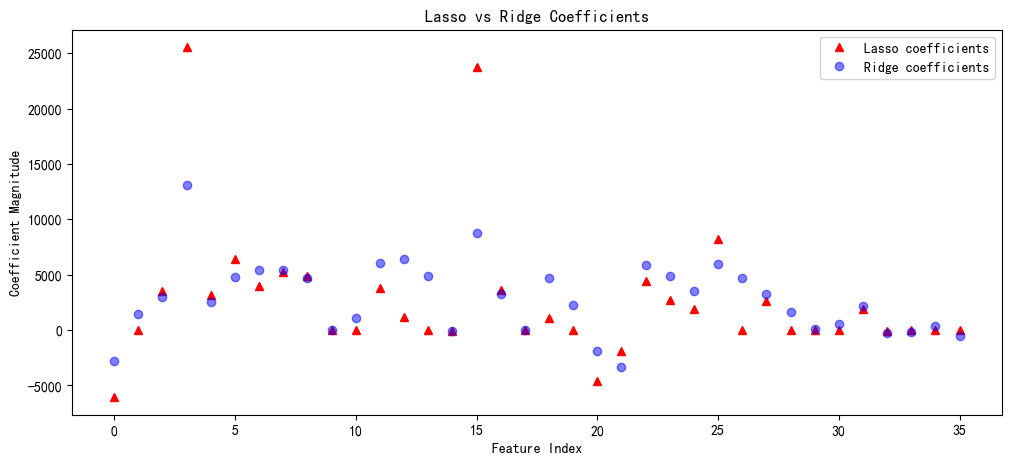

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. 准备数据 (使用全部数值特征)
data_path = '../ch-04/06_综合案例_Kaggle房价预测/train.csv'
df = pd.read_csv(data_path)
numeric_features = df.select_dtypes(include=[np.number]).drop(['Id', 'SalePrice'], axis=1).columns
X = df[numeric_features]
y = df['SalePrice']
X = SimpleImputer(strategy='median').fit_transform(X)

# 正则化对特征尺度敏感，必须先标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 训练模型
# Lasso (L1) - 倾向于稀疏解 (特征选择)
lasso = Lasso(alpha=1000) # alpha 较大，因为 SalePrice 值很大
lasso.fit(X_scaled, y)

# Ridge (L2) - 倾向于保留所有特征
ridge = Ridge(alpha=1000)
ridge.fit(X_scaled, y)

# 3. 统计非零系数
lasso_coefs = np.sum(lasso.coef_ != 0)
ridge_coefs = np.sum(ridge.coef_ != 0)
total_features = X.shape[1]

print(f"总特征数: {total_features}")
print(f"Lasso 保留特征数: {lasso_coefs}")
print(f"Ridge 保留特征数: {ridge_coefs}")

# 4. 可视化系数对比 (前20个特征)
plt.figure(figsize=(12, 5))
plt.plot(lasso.coef_, 'r^', label='Lasso coefficients')
plt.plot(ridge.coef_, 'bo', label='Ridge coefficients', alpha=0.5)
plt.title("Lasso vs Ridge Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Magnitude")
plt.legend()
plt.show()

### 5.2 早停机制

早停 (Early Stopping) 是一种被广泛使用的**隐式正则化**技巧。与 L1/L2 等显式修改损失函数的方法不同，它通过在训练过程中动态监控验证集表现，并在过拟合发生前（即验证误差开始上升时）强制停止训练，从而限制模型的复杂度。该方法是梯度提升树 (如 XGBoost, LightGBM)、神经网络以及随机梯度下降 (SGD) 等迭代式算法的标配。

#### 5.2.1 工作原理

核心思想可以概括为：**在验证集性能开始恶化之前停止训练**。

随着训练的进行，模型在**训练集**上的误差会持续下降（模型越来越拟合训练数据）。然而，在**验证集**上，误差通常呈现 **U 型曲线**：

1. **初期 (Underfitting)**：模型还在学习规律，训练误差和验证误差同时下降。
2. **后期 (Overfitting)**：模型开始死记硬背训练数据中的噪声，导致训练误差继续下降，但验证误差反而开始上升。

早停机制的目标，就是精准地捕捉到这个**转折点 (Inflection Point)**，在模型泛化能力最强的时候“冻结”参数。

#### 5.2.2 核心机制

为了保证停止策略的鲁棒性（避免因验证集误差的随机波动而过早停止），早停机制通常包含两个关键参数：

- **Patience (耐心值)**：允许验证集误差连续多少轮不下降。
  - 例如 `patience=10` 意味着：如果第 50 轮达到了最佳效果，接下来的 51-60 轮效果都变差了，那么在第 60 轮时才会触发停止。
  - 这给模型留出了一定的“观察期”，防止因局部波动而误判。
- **回滚 (Restore Best Weights)**：停止后，模型状态往往处于“耐心耗尽”的最后一轮（通常已经过拟合了）。
  - 因此，**必须**将模型参数回滚到验证效果最好的那一轮（例如第 50 轮），而不是使用停止时的参数（第 60 轮）。

#### 5.2.3 代码实战：早停效果可视化

为了演示早停的威力，我们模拟一个**容易过拟合**的场景（样本少、噪声大、模型强），并对比训练误差和验证误差的变化。

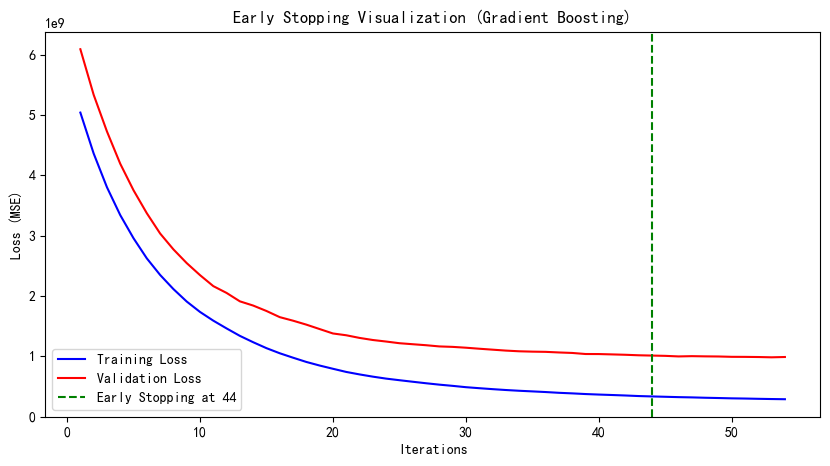

计划迭代: 1000 次
实际迭代: 54 次
最佳迭代轮次: 44


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

# 1. 准备数据
data_path = '../ch-04/06_综合案例_Kaggle房价预测/train.csv'
df = pd.read_csv(data_path)
numeric_features = df.select_dtypes(include=[np.number]).drop(['Id', 'SalePrice'], axis=1).columns
X = df[numeric_features]
y = df['SalePrice']
X = SimpleImputer(strategy='median').fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

# 2. 训练模型 (开启早停)
gb = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.1,
                               n_iter_no_change=10, validation_fraction=0.2,
                               random_state=42)
gb.fit(X_train, y_train)

# 3. 提取训练过程中的 Loss
train_loss = gb.train_score_
val_loss = [mean_squared_error(y_val, y_pred) for y_pred in gb.staged_predict(X_val)]

# 4. 可视化
plt.figure(figsize=(10, 5))
plt.plot(np.arange(gb.n_estimators_) + 1, train_loss, 'b-', label='Training Loss')
plt.plot(np.arange(gb.n_estimators_) + 1, val_loss, 'r-', label='Validation Loss')

# 标记最佳停止点
best_iter = gb.n_estimators_ - 10 # 减去 patience
plt.axvline(x=best_iter, color='g', linestyle='--', label=f'Early Stopping at {best_iter}')

plt.xlabel('Iterations')
plt.ylabel('Loss (MSE)')
plt.title('Early Stopping Visualization (Gradient Boosting)')
plt.legend()
plt.show()

print(f"计划迭代: 1000 次")
print(f"实际迭代: {gb.n_estimators_} 次")
print(f"最佳迭代轮次: {best_iter}")

## 6. 总结与建议

模型优化是一个系统性的迭代过程，建议遵循 **“诊断—数据—调参—正则”** 的标准化路径。**诊断是优化的起点**，应优先绘制学习曲线判断模型是处于“高偏差（欠拟合）”还是“高方差（过拟合）”状态，从而针对性地选择增加复杂度或增强正则化，切忌盲目试错。**数据处理是优化的基石**，在处理类别不平衡时，优先调整类别权重，必要时引入重采样技术；同时，务必将所有预处理步骤封装在 Pipeline 中，确保仅在训练集上计算统计量，从而**严防数据泄露**这一致命错误。

在模型调优阶段，推荐采用 **“先随机，后网格”** 的高效策略。先利用 `RandomizedSearchCV` 在广阔的参数空间中快速定位潜力区域，再通过 `GridSearchCV` 进行地毯式搜索。对于梯度提升树或神经网络等复杂模型，**早停** 是不可或缺的机制，它能在模型性能不再提升时及时停止训练，兼顾了效率与抗过拟合能力。在正则化选型上，**Ridge (L2)** 通常是默认的首选方案，而 **Lasso (L1)** 和 **Elastic Net** 则更适用于需要特征筛选的稀疏数据场景。

此外，开发者需时刻警惕 **盲目追求复杂模型** 的误区。在数据量有限的情况下，简单的线性模型或强正则化的模型往往具有更好的泛化能力。最后，**永远不要忽视 Baseline**，在开始复杂的优化之前，务必先建立一个简单的基准模型（如 Dummy Classifier），明确优化的起点，这样才能客观量化每一步改进的真实收益。

---

## 参考资料

1. [Scikit-Learn: Validation curves](https://scikit-learn.org/stable/modules/learning_curve.html)
2. [Imbalanced-Learn Documentation](https://imbalanced-learn.org/stable/)
3. [XGBoost Early Stopping](https://xgboost.readthedocs.io/en/stable/python/python_intro.html#early-stopping)